In [209]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import imageio
from matplotlib.animation import FuncAnimation
import utils
import seaborn as sns
import pygmt
import matplotlib.colors as mcolors
from matplotlib import colors
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec
from IPython.display import HTML
from scipy.interpolate import interp1d
from sklearn.metrics import mutual_info_score
import glob
import os
from scipy import signal
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

plt.rcParams.update({'font.size': 12})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Individual model analysis

This is a Jupyter Notebook to analyze the outputs of Motorcycle models. The outputs are for a two-fault system and the models are 2D. 

Model output directory: twofaults_input_files
Subdirectory structure: Dc_XX/output_DcXX_Ykm
where XX is the value of Dc used in that set of simulations (e.g. Dc = 1 cm is Dc_01) and Y is the spacing between the faults in km (e.g. Y = 1 km is _1km).

Model suite
| D  (km)                           |$D_c$ (m)    | DX (m) | N2  |
|-------------------------------|-------|-----|------|
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120          | 0.01  | 20  | 4096 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.008 | 20  | 4096 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.0063 | 20  | 4096 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.005 | 10  | 8192 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.0039 | 10  | 8192 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.003 | 5  | 16384 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.002 | 5  | 16384 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                   | 0.0014 | 2.5   | 32768 |
| 0.2,0.6,1,1.7,3,5,10,20,30,60,120                  | 0.001 | 2.5   | 32768 |

The only user-required inputs are in the cell below. 

In [210]:
#### this is the only cell that needs changing before running 
main_dir = "model_outputs/two_faults/antiplane/"
files_interest = ["Dc_008/output_Dc008_120km/"] 
loading_type = "Antiplane"
dc = 0.008 # Dc in RSF 
D = 120 # distance between the two parallel faults in kilometers
spin_up = 0  # keep at 0 here: metrics must span the full run so the stabilization time can be measured

In [211]:
cell_dict = {
    0.01: (20, 4096),
    0.008: (20, 4096),
    0.0063: (10, 8192),
    0.005: (10, 8192),
    0.0039: (10, 8192),
    0.003: (5, 16384),
    0.002: (5, 16384),
    0.0014: (2.5, 32768),
    0.001: (2.5, 32768) 
} # DX and N2 info for each model from Motorcycle shell scripts 

def downsample_grid(grid, dc):
    if dc > 0.005:
        return grid.coarsen(x=2, boundary='trim').mean()
    elif 0.0014 <= dc <= 0.005:      
        return grid.coarsen(x=3, boundary='trim').mean()
    else:
        return grid.coarsen(x=4, boundary='trim').mean()

In [212]:
DX, N2 = cell_dict[dc]
DX = [DX]
N2 = [N2]
cols = ['Index', 'Displacement', 'Col3', 'Col4', 'Col5', 'col', 'cplb','Slip Rate', 'Col7', 'Col8', 'Col9', 'Col10','Col11'] 
# time step conversion
time_step_rate = 20 # --export-netcdf-rate 20 \
grid_step_rate_horizontal = 4

# for calculating Ru
shear_mod = 30e9  # Shear modulus in Pa
a = 1e-2
b = a+4e-3
sigma_o = 100e6  # normal stress Pa
L = 5000 # rate-weakening length

feature = 'log10v' # tau, slip, log10v
fault1_path = main_dir + "fault-01-" + feature + ".grd"
DL = D/5
Ru = utils.estimate_Ru(shear_mod, dc, b, a, sigma_o, L)
titles = [f'Ru = {Ru:.1f}, D/L = {DL}, {loading_type}']

In [213]:
plt.rcParams.update({'font.size': 12})

for i, (file, DXi, N2i, titlei) in enumerate(zip(files_interest, DX, N2, titles)):

    # data loading
    file_pattern = main_dir + file + 'patch-01-*.dat'
    matching_files = glob.glob(file_pattern)
    fault_data = pd.read_csv(matching_files[0], sep='\s+', header=None, names=cols)

    feature = 'log10v'
    grid_fault1 = pygmt.load_dataarray(main_dir + file + "fault-01-" + feature + ".grd", engine='netcdf4')
    grid_fault2 = pygmt.load_dataarray(main_dir + file + "fault-02-" + feature + ".grd", engine='netcdf4')
    delta_grid  = time_step_rate
    time_grid   = fault_data['Index'].iloc[::int(delta_grid)].values

    grid_fault1 = downsample_grid(grid_fault1, dc)
    grid_fault2 = downsample_grid(grid_fault2, dc)

    # catalog 
    grid1_masked = np.ma.masked_where(grid_fault1 < -3.5, grid_fault1).filled(np.nan)
    grid2_masked = np.ma.masked_where(grid_fault2 < -3.5, grid_fault2).filled(np.nan)
    timestep_event_fault1, rupture_length_pixels_fault1, _, _, pixel_size = utils.find_events(grid1_masked, DXi, N2i, "No")
    timestep_event_fault2, rupture_length_pixels_fault2, _, _, _          = utils.find_events(grid2_masked, DXi, N2i, "No")
    time_f1 = time_grid[timestep_event_fault1]
    time_f2 = time_grid[timestep_event_fault2]
    rupture_length_fault1 = np.array(rupture_length_pixels_fault1)
    rupture_length_fault2 = np.array(rupture_length_pixels_fault2)

    # potency
    feature = 'slip'
    grid_fault1 = downsample_grid(pygmt.load_dataarray(main_dir + file + "fault-01-" + feature + ".grd", engine='netcdf4'), dc)
    grid_fault2 = downsample_grid(pygmt.load_dataarray(main_dir + file + "fault-02-" + feature + ".grd", engine='netcdf4'), dc)
    potency_fault1 = np.array(utils.potency(grid_fault1, DXi * grid_step_rate_horizontal))
    potency_fault2 = np.array(utils.potency(grid_fault2, DXi * grid_step_rate_horizontal))
    if len(potency_fault1) != len(time_grid):
        time_grid = time_grid[:-1]

    # remove spin up
    time_cutoff  = spin_up * 365 * 24 * 60 * 60
    cutoff_index = np.where(time_grid >= time_cutoff)[0][0]
    time_grid    = time_grid[cutoff_index:]
    time_f1 = time_f1[time_f1 >= time_cutoff]
    time_f2 = time_f2[time_f2 >= time_cutoff]
    rupture_length_fault1 = rupture_length_fault1[len(rupture_length_fault1) - len(time_f1):]
    rupture_length_fault2 = rupture_length_fault2[len(rupture_length_fault2) - len(time_f2):]

    ok1 = np.where(rupture_length_fault1 > 3)[0]
    ok2 = np.where(rupture_length_fault2 > 3)[0]
    time_f1_catalog       = time_f1[ok1]
    time_f2_catalog       = time_f2[ok2]
    rupture_length_fault1 = rupture_length_fault1[ok1]
    rupture_length_fault2 = rupture_length_fault2[ok2]

    # full ruptures only for alignment parameter estimate
    idx_full1 = np.where((rupture_length_fault1 * pixel_size) / 1000 > 4.5)[0]
    idx_full2 = np.where((rupture_length_fault2 * pixel_size) / 1000 > 4.5)[0]
    time_f1_full_yr = time_f1_catalog[idx_full1] / 365 / 24 / 60 / 60
    time_f2_full_yr = time_f2_catalog[idx_full2] / 365 / 24 / 60 / 60

    # disp time series for corr coeff
    fault_data_f1 = pd.read_csv(glob.glob(main_dir + file + 'patch-01-*.dat')[1], header=None, names=cols, sep='\s+')
    fault_data_f2 = pd.read_csv(glob.glob(main_dir + file + 'patch-02-*.dat')[1], header=None, names=cols, sep='\s+')
    fault_data_f1['Time (Years)'] = fault_data_f1['Index'].apply(utils.seconds_to_years)
    fault_data_f2['Time (Years)'] = fault_data_f2['Index'].apply(utils.seconds_to_years)

    time_years  = fault_data_f1['Time (Years)'].values
    cum_disp_f1 = fault_data_f1['Displacement'].values
    cum_disp_f2 = fault_data_f2['Displacement'].values

    # resample to regular 1-year grid post spin-up
    time_mask    = time_years >= spin_up
    time_cropped = time_years[time_mask]
    d1_cropped   = cum_disp_f1[time_mask]
    d2_cropped   = cum_disp_f2[time_mask]
    time_regular = np.arange(np.ceil(time_cropped.min()), np.floor(time_cropped.max()) + 1, 1.0)
    d1_regular   = interp1d(time_cropped, d1_cropped, kind='linear')(time_regular)
    d2_regular   = interp1d(time_cropped, d2_cropped, kind='linear')(time_regular)

    # 300-year moving window for evolution of correlation metrics
    window_yr   = 300
    step_yr     = 1
    min_events  = 3
    win_centers = np.arange(spin_up + window_yr/2, 1000 - window_yr/2 + step_yr, step_yr)

    R_win    = np.full(len(win_centers), np.nan)
    corr_win = np.full(len(win_centers), np.nan)

    # corr metrics
    for idx, tc in enumerate(win_centers):
        t_lo = tc - window_yr/2
        t_hi = tc + window_yr/2

        f1_yr_win = time_f1_full_yr[(time_f1_full_yr >= t_lo) & (time_f1_full_yr < t_hi)]
        f2_yr_win = time_f2_full_yr[(time_f2_full_yr >= t_lo) & (time_f2_full_yr < t_hi)]
        if len(f1_yr_win) >= min_events and len(f2_yr_win) >= min_events:
            phase_win = np.array([utils.get_phase(t, f1_yr_win) for t in f2_yr_win])
            phase_win = phase_win[~np.isnan(phase_win)]
            if len(phase_win) > 0:
                R_win[idx] = utils.get_order_parameter(phase_win)

        mask_disp = (time_regular >= t_lo) & (time_regular <= t_hi)
        t_win  = time_regular[mask_disp]
        d1_win = d1_regular[mask_disp]
        d2_win = d2_regular[mask_disp]
        if len(t_win) > 10:
            d1_det = d1_win - np.polyval(np.polyfit(t_win, d1_win, 1), t_win)
            d2_det = d2_win - np.polyval(np.polyfit(t_win, d2_win, 1), t_win)
            corr_win[idx], _ = pearsonr(d1_det, d2_det)

In [214]:
# spin-up selection: estimator for guidance,  value picked by clicking
%matplotlib tk

settle_R, ref_R, tol_R = utils.estimate_stabilization_time(win_centers, R_win)
settle_corr, ref_corr, tol_corr = utils.estimate_stabilization_time(win_centers, corr_win)
print(f"Alignment coefficient settles at t = {settle_R:.0f} yr (ref {ref_R:.2f} +/- {tol_R:.2f})")
print(f"Correlation coefficient settles at t = {settle_corr:.0f} yr (ref {ref_corr:.2f} +/- {tol_corr:.2f})")

# click on the popup to set the spin-up (x of click, ceiled to 10 yr); Enter = 100 yr
spin_up_est = utils.pick_spinup_interactive(win_centers, corr_win, R_win, titlei, default=100)
utils.save_spinup_estimate("code_output_data/spinup_estimates.csv",
                           loading_type, dc, D, spin_up_est)


Alignment coefficient settles at t = 150 yr (ref -0.00 +/- 0.15)
Correlation coefficient settles at t = 150 yr (ref -0.10 +/- 0.15)
Selected spin-up = 160 yr
Spin-up = 160.0 yr saved to code_output_data/spinup_estimates.csv for Antiplane, Dc=0.008, D=120


In [215]:
%matplotlib inline

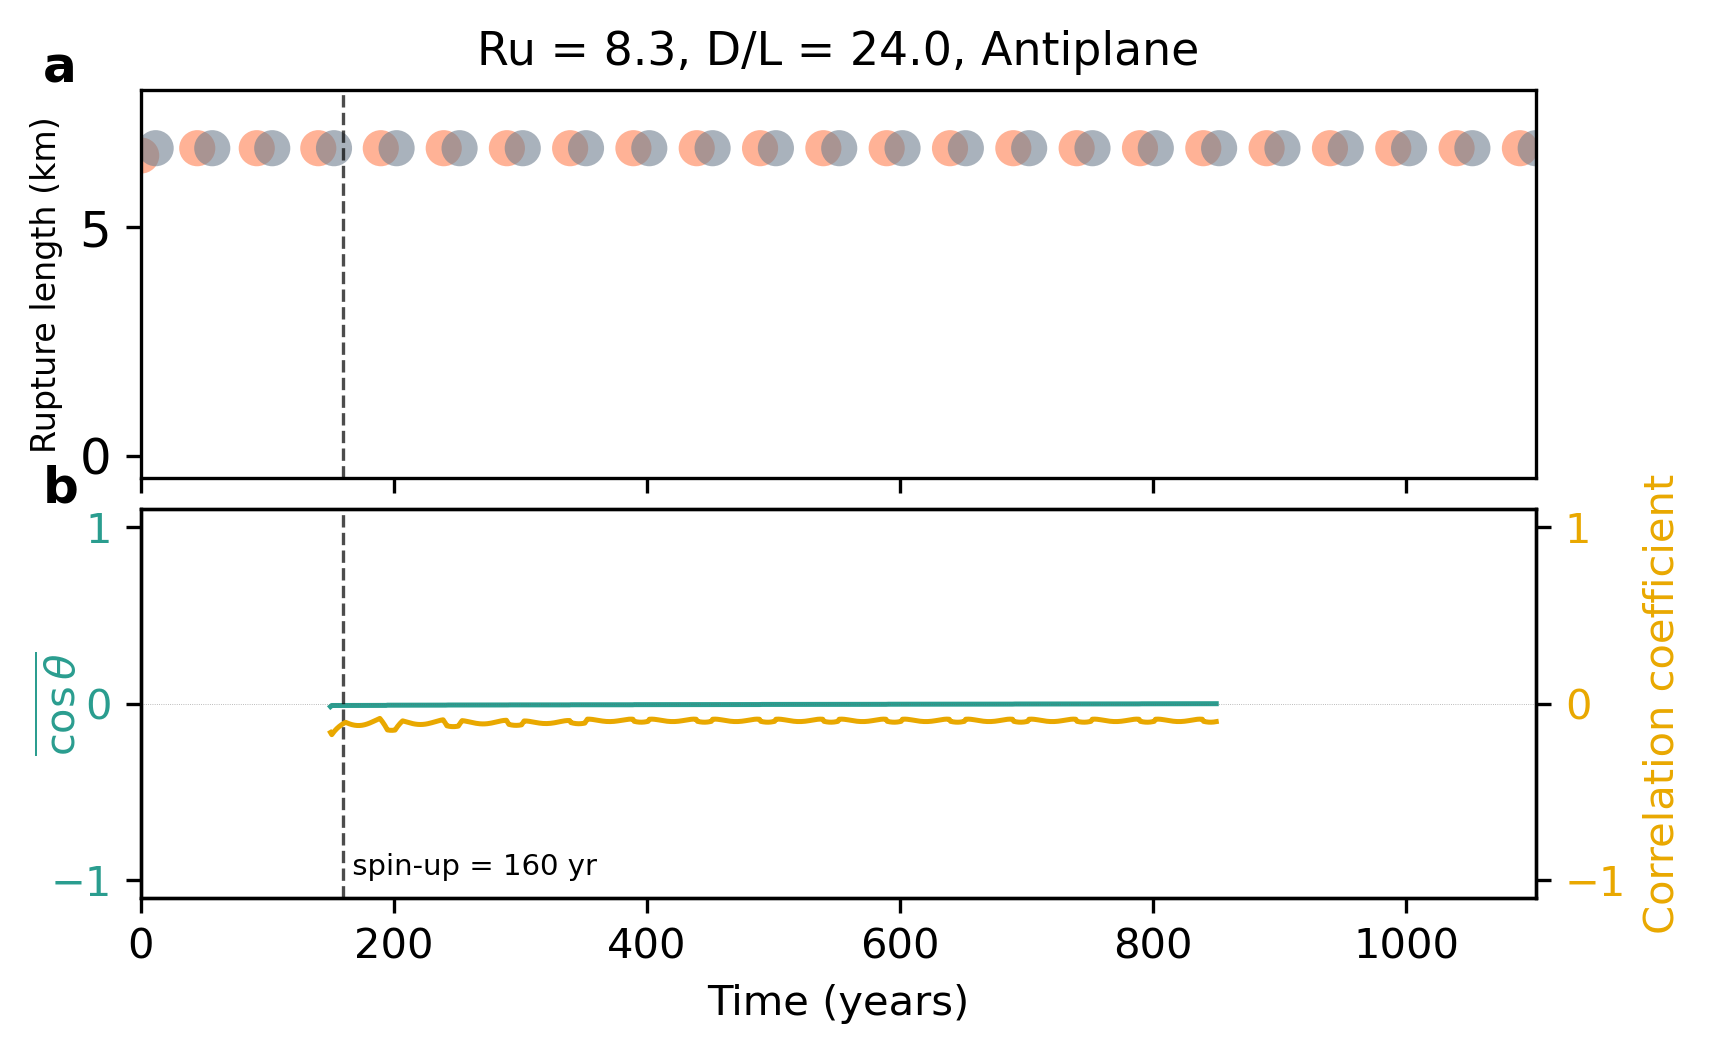

In [216]:
    fig, (ax_cat, ax_both) = plt.subplots(
        2, 1, figsize=(6, 3.5), dpi=300, sharex=True,
        gridspec_kw=dict(hspace=0.08, height_ratios=[1, 1])
    )

    scale_factor = 20
    ax_cat.scatter(time_f1_catalog / 365 / 24 / 60 / 60,
                   (rupture_length_fault1 * pixel_size) / 1000,
                   c='coral', s=scale_factor * np.log(rupture_length_fault1 + 1),
                alpha=0.6, edgecolor='none', label='Fault 1')
    ax_cat.scatter(time_f2_catalog / 365 / 24 / 60 / 60,
                   (rupture_length_fault2 * pixel_size) / 1000,
                   c='slategray', s=scale_factor * np.log(rupture_length_fault2 + 1),
                alpha=0.6, edgecolor='none', label='Fault 2')
    ax_cat.set_ylabel('Rupture length (km)', fontsize=8)
    ax_cat.set_ylim(-0.5, 8)
    ax_cat.set_title(titlei, fontsize=11)
    ax_cat.text(-0.07, 1.02, 'a', transform=ax_cat.transAxes, fontsize=12, fontweight='bold')

    color_R    = '#2a9d8f'
    color_corr = '#e9a800'
    ax_both.plot(win_centers, R_win, color=color_R, linewidth=1.2, label=r'$\overline{\cos\theta}$')
    ax_both.set_ylabel(r'$\overline{\cos\theta}$', color=color_R, fontsize=10, labelpad=1)
    ax_both.yaxis.set_label_coords(-0.04, 0.5) 
    ax_both.set_ylim(-1.1, 1.1)
    ax_both.tick_params(axis='y', labelcolor=color_R, labelsize=10)
    ax_both.text(-0.07, 1.02, 'b', transform=ax_both.transAxes, fontsize=12, fontweight='bold')

    ax_twin = ax_both.twinx()
    ax_twin.plot(win_centers, corr_win, color=color_corr, linewidth=1.2, label='Disp. corr.')
    ax_twin.axhline(0, linestyle=':', color='dimgray', linewidth=0.2, alpha=0.6)
    ax_twin.set_ylabel('Correlation coefficient', color=color_corr, fontsize=10)
    ax_twin.set_ylim(-1.1, 1.1)
    ax_twin.tick_params(axis='y', labelcolor=color_corr, labelsize=10)

    if 'spin_up_est' in dir() and not np.isnan(spin_up_est):
        for ax in (ax_cat, ax_both):
            ax.axvline(spin_up_est, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
        ax_both.text(spin_up_est, -1.0, f' spin-up = {spin_up_est:.0f} yr', fontsize=7, va='bottom')

    ax_both.set_xlabel('Time (years)', fontsize=10)
    ax_both.tick_params(axis='x', labelsize=10)

    x_max = max(time_f1_catalog.max(), time_f2_catalog.max()) / 365 / 24 / 60 / 60
    for ax in (ax_cat, ax_both):
        ax.set_xlim(spin_up, x_max)

    titlei_clean = titlei.replace('$', '').replace('_', '').replace('/', '')
    plt.savefig(f'Summary figures/Moving window metrics/{titlei_clean}_evolution.png', bbox_inches='tight')
